In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/icu_analytics_v2.csv"
)

df["age_numeric"] = pd.to_numeric(
    df["age"].replace("> 89", "90"),
    errors="coerce"
)

df.head()

,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,hospitaladmitsource,hospitaldischargestatus,...,n_medication_records,n_lab_records,apache_score,predicted_icu_mortality,predicted_icu_los,actual_vent_days,apache_version,ventilation_status,ventilation_data_available,age_numeric
0,141764,129391,Female,87,Caucasian,59,91,NaN,NaN,Alive,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,87.0
1,141765,129391,Female,87,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",NaN,Alive,...,14.0,72.0,47.0,0.012311,1.374807,NaN,IVa,Unknown,0.0,87.0
2,143870,131022,Male,76,Caucasian,68,103,"Endarterectomy, carotid",Operating Room,Alive,...,40.0,49.0,60.0,0.015707,3.021671,NaN,IVa,Unknown,0.0,76.0
3,144815,131736,Female,34,Caucasian,56,82,"Overdose, other toxin, poison or drug",Emergency Department,Alive,...,5.0,74.0,25.0,0.002133,0.806311,NaN,IVa,Unknown,0.0,34.0
4,145427,132209,Male,61,Caucasian,68,103,"GI perforation/rupture, surgery for",Emergency Department,Alive,...,40.0,94.0,37.0,0.007556,3.503540,NaN,IVa,Unknown,0.0,61.0


In [16]:
df[
    [
        "los_days",
        "apache_score",
        "predicted_icu_mortality",
        "predicted_icu_los",
        "actual_vent_days"
    ]
].describe()

,los_days,apache_score,predicted_icu_mortality,predicted_icu_los,actual_vent_days
count,2520.000000,1797.000000,1.753000e+03,1753.000000,521.000000
mean,2.419497,53.164719,6.235082e-02,3.661441,3.385797
std,3.456362,24.223845,1.191213e-01,2.097689,3.706402
min,0.000000,0.000000,3.471517e-09,0.134759,1.000000
25%,0.790104,36.000000,8.332072e-03,2.102504,1.000000
50%,1.472222,49.000000,2.146575e-02,3.130090,2.000000
75%,2.776736,66.000000,5.626055e-02,4.702404,4.000000
max,46.179861,185.000000,8.698576e-01,11.905753,30.000000


In [17]:
icu_summary = (
    df.groupby("unittype")
    .agg(
        stays=("patientunitstayid", "nunique"),
        avg_los=("los_days", "mean"),
        mortality=("icu_death", "mean"),
        avg_apache=("apache_score", "mean")
    )
    .sort_values("avg_los", ascending=False)
)

icu_summary

,stays,avg_los,mortality,avg_apache
unittype,,,,
CTICU,52,3.074225,0.038462,51.108696
SICU,83,2.861647,0.048193,54.688525
CCU-CTICU,82,2.705835,0.073171,50.695652
Cardiac ICU,133,2.482738,0.045113,50.731481
Med-Surg ICU,1898,2.396998,0.050053,52.966317
MICU,142,2.324780,0.049296,60.480392
Neuro ICU,65,2.309968,0.061538,48.588235
CSICU,65,1.813889,0.030769,60.958333


In [18]:
df.groupby(
    "ventilation_status"
)["los_days"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
ventilation_status,,,
Unknown,1999,1.972076,1.248611
Ventilated,521,4.136184,2.594444


In [19]:
df.groupby(
    "ventilation_status"
)["icu_death"].mean()

ventilation_status
Unknown       0.034517
Ventilated    0.109405
Name: icu_death, dtype: float64

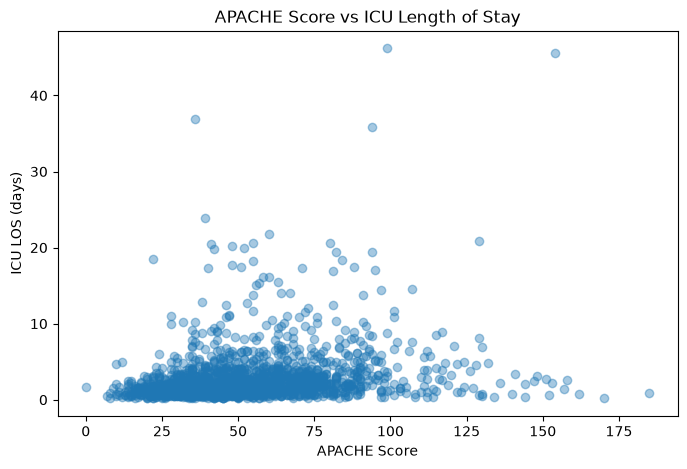

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["apache_score"],
    df["los_days"],
    alpha=0.4
)

plt.xlabel("APACHE Score")
plt.ylabel("ICU LOS (days)")
plt.title("APACHE Score vs ICU Length of Stay")

plt.show()

In [21]:
df["actual_vent_days"] = pd.to_numeric(
    df["actual_vent_days"],
    errors="coerce"
)

In [22]:
df["ventilation_status"] = "Unknown"

df.loc[
    df["actual_vent_days"] > 0,
    "ventilation_status"
] = "Ventilated"

df.loc[
    df["actual_vent_days"] == 0,
    "ventilation_status"
] = "Not ventilated"

In [23]:
df["ventilation_status"].value_counts(
    dropna=False
)

ventilation_status
Unknown       1999
Ventilated     521
Name: count, dtype: int64

In [24]:
df.groupby(
    "ventilation_status"
)["los_days"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
ventilation_status,,,
Unknown,1999,1.972076,1.248611
Ventilated,521,4.136184,2.594444


In [25]:
df.groupby(
    "ventilation_status"
)["icu_death"].mean()

ventilation_status
Unknown       0.034517
Ventilated    0.109405
Name: icu_death, dtype: float64

In [26]:
df.to_csv(
    "../data/processed/icu_analytics_v2.csv",
    index=False
)

In [27]:
test = pd.read_csv(
    "../data/processed/icu_analytics_v2.csv"
)

print(
    "ventilation_status" in test.columns
)

True


In [28]:
mortality_by_unit = (
    df.groupby("unittype")
    .agg(
        observed_mortality=("icu_death", "mean"),
        predicted_mortality=("predicted_icu_mortality", "mean"),
        stays=("patientunitstayid", "nunique")
    )
    .sort_values("observed_mortality", ascending=False)
)

mortality_by_unit

,observed_mortality,predicted_mortality,stays
unittype,,,
CCU-CTICU,0.073171,0.044866,82
Neuro ICU,0.061538,0.075315,65
Med-Surg ICU,0.050053,0.062836,1898
MICU,0.049296,0.079575,142
SICU,0.048193,0.066763,83
Cardiac ICU,0.045113,0.051632,133
CTICU,0.038462,0.042708,52
CSICU,0.030769,0.057640,65


In [29]:
mortality_by_unit["observed_mortality_pct"] = (
    mortality_by_unit["observed_mortality"] * 100
)

mortality_by_unit["predicted_mortality_pct"] = (
    mortality_by_unit["predicted_mortality"] * 100
)

mortality_by_unit[
    [
        "stays",
        "observed_mortality_pct",
        "predicted_mortality_pct"
    ]
].round(2)

,stays,observed_mortality_pct,predicted_mortality_pct
unittype,,,
CCU-CTICU,82,7.32,4.49
Neuro ICU,65,6.15,7.53
Med-Surg ICU,1898,5.01,6.28
MICU,142,4.93,7.96
SICU,83,4.82,6.68
Cardiac ICU,133,4.51,5.16
CTICU,52,3.85,4.27
CSICU,65,3.08,5.76
